<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/kikim6114/Intro2DL/blob/main/12.Fashion_MNIST_ConvNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

In [1]:
# Colab이나 Kaggle을 사용하는 경우가 아니면, 이 cell을 모두 주석화하여 skip할 것.
# Colab 런타임 유형을 반드시 GPU로 선택할 것.
import os

repository_name = 'Intro2DL'
repository_url = f'https://github.com/kikim6114/{repository_name}.git'

# 항상 루트 경로(/content/)로 이동 후 확인
%cd /content/

if not os.path.exists(repository_name):
    !git clone {repository_url}
    print(f"{repository_name} 클론 완료")
else:
    print(f"{repository_name} 폴더가 이미 존재합니다. 클론을 건너뜁니다.")
%cd {repository_name}

/content
Cloning into 'Intro2DL'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 13 (delta 2), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 141.50 KiB | 11.79 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Intro2DL 클론 완료
/content/Intro2DL


In [2]:
# Jupyter Notebook용 TensorFlow Keras Fashion-MNIST Classification 코드

# 1. 필요한 라이브러리 임포트
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import sys

In [3]:
# 2. Fashion-MNIST 데이터셋 로드
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# 클래스 이름 정의 (Fashion-MNIST 레이블에 대응)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# 3. 데이터 전처리
# 이미지 정규화 (0~255 -> 0~1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 데이터 차원 조정 (Conv2D 입력을 위해 채널 차원 추가)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 레이블을 원-핫 인코딩
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [5]:
# 4. CNN 모델 구축
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),  # Input 레이어 추가
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [6]:
# 5. 모델 컴파일
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 모델 요약 출력
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,890 (511.29 KB)

 Trainable params: 130,890 (511.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 6. 모델 학습
history = model.fit(x_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.2)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7560 - loss: 0.6708 - val_accuracy: 0.8443 - val_loss: 0.4182
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8521 - loss: 0.4127 - val_accuracy: 0.8755 - val_loss: 0.3376
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8752 - loss: 0.3504 - val_accuracy: 0.8814 - val_loss: 0.3143
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8854 - loss: 0.3163 - val_accuracy: 0.8914 - val_loss: 0.2898
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8957 - loss: 0.2899 - val_accuracy: 0.8987 - val_loss: 0.2760
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9045 - loss: 0.2678 - val_accuracy: 0.9007 - val_loss: 0.2676
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9084 - loss: 0.2499 - val_accuracy: 0.9039 - val_loss: 0.2576
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9165 - loss: 0.2323 - val_accuracy: 0.

In [8]:
# 7. 모델 평가
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'\n테스트 정확도: {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9112 - loss: 0.2598

테스트 정확도: 0.9112


In [9]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

import sys
# 코랩의 경우 나눔 폰트를 설치합니다.
if 'google.colab' in sys.modules:
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

# 나눔 폰트를 사용합니다.
import matplotlib

matplotlib.rc('font', family='NanumGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...


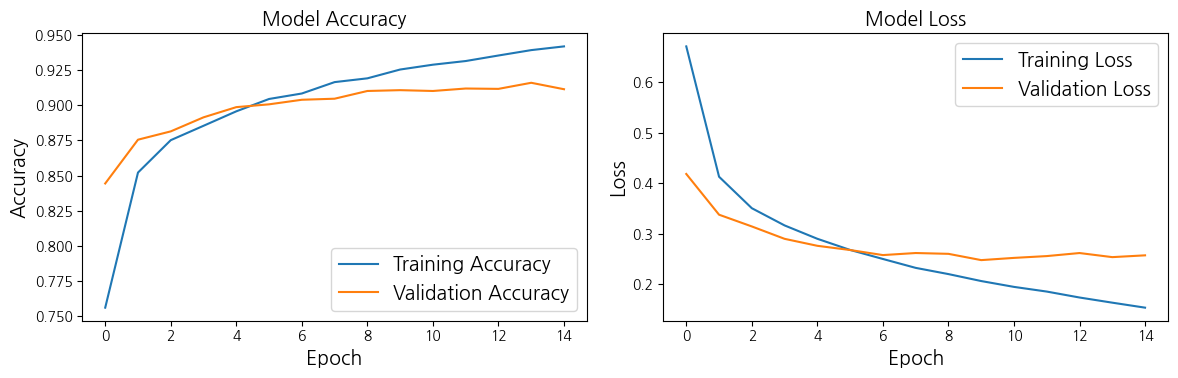

In [10]:
# 8. 학습 과정 시각화
# 정확도 그래프
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 손실 그래프
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step


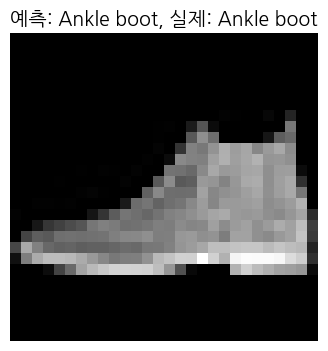

In [11]:
# 9. 예측
# 테스트 데이터에서 샘플 이미지 선택
sample_idx = 0
sample_image = x_test[sample_idx]
sample_label = y_test[sample_idx]

# 예측 수행
pred = model.predict(sample_image.reshape(1, 28, 28, 1))
pred_label = np.argmax(pred)
true_label = np.argmax(sample_label)

# 이미지와 예측 결과 시각화
plt.figure(figsize=(4, 4))
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f'예측: {class_names[pred_label]}, 실제: {class_names[true_label]}')
plt.axis('off')
plt.show()

## 풀링층이 없다면?

In [12]:
model_with_no_pooling = models.Sequential([
    layers.Input(shape=(28, 28, 1)),  # Input 레이어 추가
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [13]:
# 5. 모델 컴파일
model_with_no_pooling.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 모델 요약 출력
model_with_no_pooling.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 22, 22, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,022,090 (15.34 MB)

 Trainable params: 4,022,090 (15.34 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# 6. 모델 학습
history = model_with_no_pooling.fit(x_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.2)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8182 - loss: 0.5123 - val_accuracy: 0.8795 - val_loss: 0.3192
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8840 - loss: 0.3234 - val_accuracy: 0.9034 - val_loss: 0.2594
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9022 - loss: 0.2669 - val_accuracy: 0.9108 - val_loss: 0.2467
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9172 - loss: 0.2249 - val_accuracy: 0.9117 - val_loss: 0.2395
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9279 - loss: 0.1930 - val_accuracy: 0.9198 - val_loss: 0.2342
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9397 - loss: 0.1644 - val_accuracy: 0.9226 - val_loss: 0.2450
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9474 - loss: 0.1418 - val_accuracy: 0.9206 - val_loss: 0.2542
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9550 - loss: 0.1202 - val_accuracy: 0

In [15]:
# 7. 모델 평가
test_loss, test_acc = model_with_no_pooling.evaluate(x_test, y_test)
print(f'\n테스트 정확도: {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9183 - loss: 0.3743

테스트 정확도: 0.9183


In [16]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

import sys
# 코랩의 경우 나눔 폰트를 설치합니다.
if 'google.colab' in sys.modules:
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

# 나눔 폰트를 사용합니다.
import matplotlib

matplotlib.rc('font', family='NanumGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

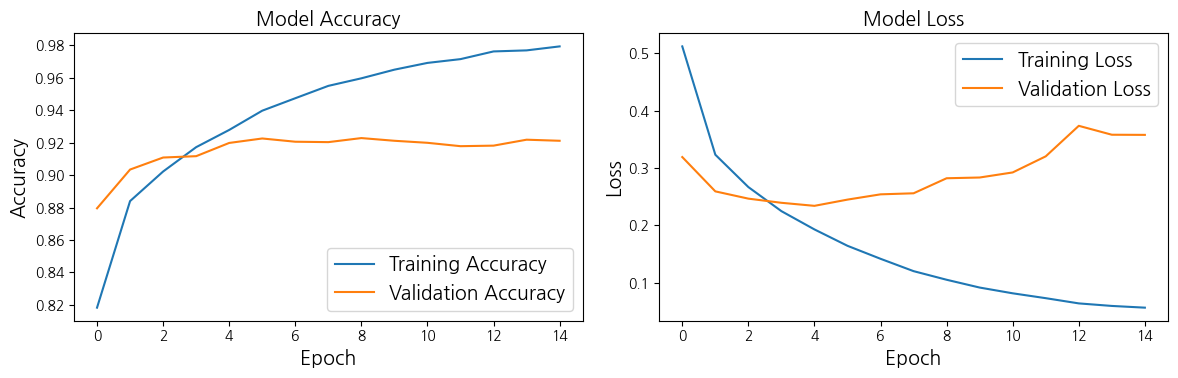

In [17]:
# 8. 학습 과정 시각화
# 정확도 그래프
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 손실 그래프
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step


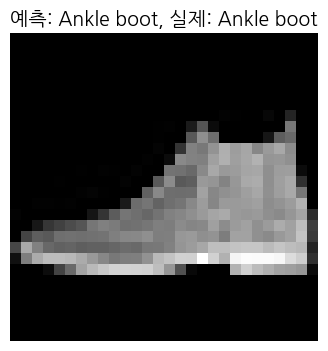

In [18]:
# 9. 예측
# 테스트 데이터에서 샘플 이미지 선택
sample_idx = 0
sample_image = x_test[sample_idx]
sample_label = y_test[sample_idx]

# 예측 수행
pred = model_with_no_pooling.predict(sample_image.reshape(1, 28, 28, 1))
pred_label = np.argmax(pred)
true_label = np.argmax(sample_label)

# 이미지와 예측 결과 시각화
plt.figure(figsize=(4, 4))
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f'예측: {class_names[pred_label]}, 실제: {class_names[true_label]}')
plt.axis('off')
plt.show()